#### 파이썬 코드로 GPU 가속 상태 확인하기

In [1]:
import torch

print("============================================================")
print("🖥️  [입찰메이트] 로컬 GPU 가속 및 하드웨어 인프라 진단 리포트")
print("============================================================")

# 1. CUDA(GPU 가속 엔진) 사용 가능 여부 체크
cuda_available = torch.cuda.is_available()
print(f"🚀 1. 현재 PyTorch의 GPU(CUDA) 가속 가동 여부: {'[사용 가능] ✔' if cuda_available else '[사용 불가/CPU 구동] ❌'}")

if cuda_available:
    # 2. 내 컴퓨터에 장착된 Nvidia 그래픽카드 정보 추출
    current_device = torch.cuda.current_device()
    device_name = torch.cuda.get_device_name(current_device)
    
    # 3. GPU 메모리 용량 체크 (단위: GB)
    total_memory = torch.cuda.get_device_properties(current_device).total_memory / (1024**3)
    
    print(f"🎮 2. 탐지된 NVIDIA 그래픽카드 모델명 : {device_name}")
    print(f"💾 3. 장착된 총 VRAM(그래픽 메모리) 용량: {total_memory:.2f} GB")
    
    # RAG 최적화 진단
    if total_memory < 8:
        print("💡 [엔진 진단]: VRAM이 8GB 미만입니다. 향후 Qwen2-7B LLM 구동 시 4비트 양자화(Quantization) 로드가 권장됩니다.")
    else:
        print("💡 [엔진 진단]: VRAM이 충분합니다! Qwen2-7B 및 KURE-v1 임베딩 모델을 안정적으로 고속 추론할 수 있습니다.")
else:
    print("💡 [해결책]: 만약 외장 그래픽카드가 있는데 ❌가 뜬다면, 가상환경에 일반 CPU용 PyTorch가 깔린 것입니다.")
    print("   👉 가상환경 터미널에서 'pip install torch --index-url https://pytorch.org 실행해 CUDA 버전을 맞춰주세요.")
print("============================================================")


🖥️  [입찰메이트] 로컬 GPU 가속 및 하드웨어 인프라 진단 리포트
🚀 1. 현재 PyTorch의 GPU(CUDA) 가속 가동 여부: [사용 가능] ✔
🎮 2. 탐지된 NVIDIA 그래픽카드 모델명 : NVIDIA GeForce RTX 3070
💾 3. 장착된 총 VRAM(그래픽 메모리) 용량: 8.00 GB
💡 [엔진 진단]: VRAM이 8GB 미만입니다. 향후 Qwen2-7B LLM 구동 시 4비트 양자화(Quantization) 로드가 권장됩니다.


In [4]:
# ==============================================================================
# 🌟 [01_data_eda] Step 1: 중단 시점 자동 이어받기(Resume) 탑재형 파서
# ==============================================================================

import os
import re
import json
import hashlib
import subprocess
from glob import glob
from typing import List, Dict, Any
import pandas as pd
from dotenv import load_dotenv

load_dotenv(override=True)
from llama_parse import LlamaParse

BASE_DIR = r"D:\codeit\RAG\RFP-RAG-Extractor"
RAW_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

# 최종 컴파일 폴더 경로 및 파일 이름 정의
TARGET_OUTPUT_DIR = r"D:\codeit\RAG\RFP-RAG-Extractor\data\processed\light_cleaned_jason"
OUTPUT_JSON_PATH = os.path.join(TARGET_OUTPUT_DIR, "rfp_meta_eda.json")

# 폴더 자동 방어 생성
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(TARGET_OUTPUT_DIR, exist_ok=True)

class BidMateResumeBatchLoader:
    def __init__(self):
        llama_key = os.getenv("LLAMA_CLOUD_API_KEY")
        self.pdf_parser = LlamaParse(
            api_key=llama_key,
            result_type="markdown",
            language="ko",
            parsing_instruction="이 문서는 공공입찰 제안요청서입니다. 내부 모든 표 구조를 마크다운 테이블 규격(|---|---|)으로 복원해라."
        )

    def _load_hwp_table_via_pyhwp(self, file_path: str) -> str:
        try:
            result = subprocess.run(
                ["hwp5html", file_path], 
                capture_output=True, 
                text=True, 
                encoding="utf-8", 
                errors="ignore",
                check=True
            )
            return result.stdout
        except Exception:
            try:
                res_txt = subprocess.run(["hwp5txt", file_path], capture_output=True, text=True, encoding="utf-8", errors="ignore")
                return res_txt.stdout
            except:
                return ""

    def load_single_file(self, file_path: str) -> List[Dict[str, Any]]:
        filename = os.path.basename(file_path)
        ext = os.path.splitext(filename)[-1].lower()
        page_assets = []
        try:
            if ext == ".hwp":
                hwp_html_content = self._load_hwp_table_via_pyhwp(file_path)
                if hwp_html_content.strip():
                    page_assets.append({"page_number": 1, "raw_text": hwp_html_content})
            elif ext == ".pdf":
                llama_docs = self.pdf_parser.load_data(file_path)
                for idx, l_doc in enumerate(llama_docs):
                    page_assets.append({"page_number": idx + 1, "raw_text": l_doc.text})
        except Exception:
            pass
        return page_assets

    def process_directory_safely(self, dir_path: str) -> List[Dict[str, Any]]:
        hwp_files = glob(os.path.join(dir_path, "*.hwp")) + glob(os.path.join(dir_path, "*.HWP"))
        pdf_files = glob(os.path.join(dir_path, "*.pdf")) + glob(os.path.join(dir_path, "*.PDF"))
        target_files = sorted(list(set(hwp_files + pdf_files)))
        total_count = len(target_files)
        
        # --- [핵심 엔지니어링 레이어] 기존 백업 데이터 로드 및 중복 탐지 방어선 ---
        all_flattened_results = []
        processed_filenames = set()
        
        if os.path.exists(OUTPUT_JSON_PATH):
            try:
                with open(OUTPUT_JSON_PATH, "r", encoding="utf-8") as f:
                    all_flattened_results = json.load(f)
                # 이미 디스크 저장까지 완료된 고유 파일 명단 추출
                processed_filenames = set([item["filename"] for item in all_flattened_results])
                print(f"📦 [체크포인트 복구] 기존에 저장 완료된 문서 {len(processed_filenames)}개를 발견했습니다.")
                print(f"🚀 {len(processed_filenames) + 1}번 파일부터 성공적으로 이어받기를 개시합니다.\n" + "-"*75)
            except Exception:
                print("⚠️ 기존 파일 손상 또는 읽기 실패. 처음부터 파싱을 리스타트합니다.")
                all_flattened_results = []
        else:
            print(f"📊 [입찰메이트] 분할 안전 모드 초기 가동: 총 {total_count}개 문서 최초 스캔 시작.\n" + "-"*75)
        
        # 102개 문서 루프 가동
        for idx, f_path in enumerate(target_files, start=1):
            filename = os.path.basename(f_path)
            file_size_kb = round(os.path.getsize(f_path) / 1024, 2)
            
            # 이미 처리했던 이력이 있는 파일명은 연산 연산 없이 즉시 패스(Skip)
            if filename in processed_filenames:
                continue
                
            print(f"🔄 [{idx}/{total_count}] 이어받아 분석 중: {filename[:25]}... ({file_size_kb} KB)", end="\r")
            
            pages = self.load_single_file(f_path)
            
            for p in pages:
                clean_body = "".join(p["raw_text"].split())
                page_hash = hashlib.md5(clean_body.encode('utf-8')).hexdigest()
                has_table_structure = "<table>" in p["raw_text"] or ("|" in p["raw_text"] and "---" in p["raw_text"])
                
                all_flattened_results.append({
                    "filename": filename,
                    "file_type": os.path.splitext(filename)[-1].replace(".", "").lower(),
                    "file_size_kb": file_size_kb,
                    "page_number": p["page_number"],
                    "page_hash": page_hash,
                    "text_length": len(p["raw_text"]),
                    "has_table_structure": has_table_structure,
                    "raw_content": p["raw_text"]
                })
            
            # 10개 혹은 마지막 문서 도달 시 하드디스크 쓰기(Sync)
            if idx % 10 == 0 or idx == total_count:
                with open(OUTPUT_JSON_PATH, "w", encoding="utf-8") as f:
                    json.dump(all_flattened_results, f, ensure_ascii=False, indent=4)
                print(f"\n💾 [체크포인트] {idx}번 문서까지의 누적 결과가 디스크에 업데이트 저장되었습니다.")
                
        return all_flattened_results

# 파이프라인 안전 복구 및 가동
free_loader = BidMateResumeBatchLoader()
raw_parsed_results = free_loader.process_directory_safely(RAW_DIR)
print(f"\n🎉 최종 성공: 102개 전체 문서가 누락 없이 디스크 고속 저장 완료되었습니다. 총 {len(raw_parsed_results)}개 페이지 에셋 확보.")


📊 [입찰메이트] 분할 안전 모드 초기 가동: 총 100개 문서 최초 스캔 시작.
---------------------------------------------------------------------------
🔄 [10/100] 이어받아 분석 중: 경기도사회서비스원_2024년 통합사회정보시스템... (568.0 KB))
💾 [체크포인트] 10번 문서까지의 누적 결과가 디스크에 업데이트 저장되었습니다.
Started parsing the file under job_id 6fd6346b-baca-4804-a5c5-e40dde1fbf3b
🔄 [20/100] 이어받아 분석 중: 국립중앙의료원_(긴급)「2024년도 차세대 응... (1483.5 KB)
💾 [체크포인트] 20번 문서까지의 누적 결과가 디스크에 업데이트 저장되었습니다.
Error while parsing the file 'D:\codeit\RAG\RFP-RAG-Extractor\data\raw\기초과학연구원_2025년도 중이온가속기용 극저온시스템 운전 용역.pdf': Event loop is closed
🔄 [30/100] 이어받아 분석 중: 대전대학교_대전대학교 2024학년도 다층적 융... (1017.0 KB)
💾 [체크포인트] 30번 문서까지의 누적 결과가 디스크에 업데이트 저장되었습니다.
Started parsing the file under job_id 8c801f1d-54aa-470c-bd96-ca3cc024082f
.......
💾 [체크포인트] 40번 문서까지의 누적 결과가 디스크에 업데이트 저장되었습니다.
Error while parsing the file 'D:\codeit\RAG\RFP-RAG-Extractor\data\raw\서울특별시_2024년 지도정보 플랫폼 및 전문활용 연계 시스템 고도화 용.pdf': Event loop is closed
🔄 [50/100] 이어받아 분석 중: 인천광역시 동구_수도국산달동네박물관 전시해설 ... (787.5 KB))
💾 [체크포인트] 5

In [2]:
# ==============================================================================
# 🌟 [01_data_eda] Step 1: 대량 처리 맞춤형 분할 저장 고속 파서 (최종 인프라 패치) - 원래 1번 셀 도중 중단됨
# ==============================================================================

import os
import re
import json
import hashlib
import subprocess
from glob import glob
from typing import List, Dict, Any
import pandas as pd
from dotenv import load_dotenv

load_dotenv(override=True)
from llama_parse import LlamaParse

BASE_DIR = r"D:\codeit\RAG\RFP-RAG-Extractor"
RAW_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
OUTPUT_JSON_PATH = os.path.join(PROCESSED_DIR, "rfp_meta_eda.json")

os.makedirs(PROCESSED_DIR, exist_ok=True)

class BidMateBatchLoader:
    def __init__(self):
        llama_key = os.getenv("LLAMA_CLOUD_API_KEY")
        self.pdf_parser = LlamaParse(
            api_key=llama_key,
            result_type="markdown",
            language="ko",
            parsing_instruction="이 문서는 공공입찰 제안요청서입니다. 내부 모든 표 구조를 마크다운 테이블 규격(|---|---|)으로 복원해라."
        )

    def _load_hwp_table_via_pyhwp(self, file_path: str) -> str:
        try:
            result = subprocess.run(
                ["hwp5html", file_path], 
                capture_output=True, 
                text=True, 
                encoding="utf-8", 
                errors="ignore",
                check=True
            )
            return result.stdout
        except Exception:
            try:
                res_txt = subprocess.run(["hwp5txt", file_path], capture_output=True, text=True, encoding="utf-8", errors="ignore")
                return res_txt.stdout
            except:
                return ""

    def load_single_file(self, file_path: str) -> List[Dict[str, Any]]:
        filename = os.path.basename(file_path)
        ext = os.path.splitext(filename)[-1].lower()
        page_assets = []
        try:
            if ext == ".hwp":
                hwp_html_content = self._load_hwp_table_via_pyhwp(file_path)
                if hwp_html_content.strip():
                    page_assets.append({"page_number": 1, "raw_text": hwp_html_content})
            elif ext == ".pdf":
                llama_docs = self.pdf_parser.load_data(file_path)
                for idx, l_doc in enumerate(llama_docs):
                    page_assets.append({"page_number": idx + 1, "raw_text": l_doc.text})
        except Exception:
            pass
        return page_assets

    def process_directory_safely(self, dir_path: str):
        hwp_files = glob(os.path.join(dir_path, "*.hwp")) + glob(os.path.join(dir_path, "*.HWP"))
        pdf_files = glob(os.path.join(dir_path, "*.pdf")) + glob(os.path.join(dir_path, "*.PDF"))
        target_files = sorted(list(set(hwp_files + pdf_files)))
        
        total_count = len(target_files)
        print(f"📊 [입찰메이트] 분할 안전 모드 기동: 총 {total_count}개 타깃 문서 스캔 시작.")
        print("-" * 75)
        
        # 중간 점검을 위해 기존 파일이 있다면 백업 후 초기화
        all_flattened_results = []
        
        for idx, f_path in enumerate(target_files, start=1):
            filename = os.path.basename(f_path)
            file_size_kb = round(os.path.getsize(f_path) / 1024, 2)
            
            # 🖥️ 랙(Lag)과 멈춤 방지를 위해 1줄로 축소 출력
            print(f"🔄 [{idx}/{total_count}] 전처리 분석 중: {filename[:25]}... ({file_size_kb} KB)", end="\r")
            
            pages = self.load_single_file(f_path)
            
            for p in pages:
                clean_body = "".join(p["raw_text"].split())
                page_hash = hashlib.md5(clean_body.encode('utf-8')).hexdigest()
                has_table_structure = "<table>" in p["raw_text"] or ("|" in p["raw_text"] and "---" in p["raw_text"])
                
                all_flattened_results.append({
                    "filename": filename,
                    "file_type": os.path.splitext(filename)[-1].replace(".", "").lower(),
                    "file_size_kb": file_size_kb,
                    "page_number": p["page_number"],
                    "page_hash": page_hash,
                    "text_length": len(p["raw_text"]),
                    "has_table_structure": has_table_structure,
                    "raw_content": p["raw_text"]
                })
            
            # [실무 오버플로우 방어 패치]: 10개 문서 처리할 때마다 하드디스크에 임시 임프린트 저장하여 메모리 비우기
            if idx % 10 == 0 or idx == total_count:
                with open(OUTPUT_JSON_PATH, "w", encoding="utf-8") as f:
                    json.dump(all_flattened_results, f, ensure_ascii=False, indent=4)
                print(f"\n💾 [체크포인트] {idx}번 문서까지의 결과가 디스크에 중간 백업 완료되었습니다.")
                
        return all_flattened_results

# 파이프라인 안전 가동
free_loader = BidMateBatchLoader()
raw_parsed_results = free_loader.process_directory_safely(RAW_DIR)
print(f"\n🎉 최종 성공: 102개 전체 문서가 디스크 고속 동기화 저장 완료되었습니다. 총 {len(raw_parsed_results)}개 에셋 확보.")


C:\Users\sooqw\AppData\Local\Temp\ipykernel_35188\2843273342.py:16: DeprecationWarning: The 'llama-parse' package is deprecated and will no longer receive updates. Please migrate to the new unified SDK. See https://developers.llamaindex.ai/python/cloud/llamaparse/getting_started/ and https://github.com/run-llama/llama-cloud-py/blob/main/README.md for migration instructions.
  from llama_parse import LlamaParse


📊 [입찰메이트] 분할 안전 모드 기동: 총 100개 타깃 문서 스캔 시작.
---------------------------------------------------------------------------
🔄 [10/100] 전처리 분석 중: 경기도사회서비스원_2024년 통합사회정보시스템... (568.0 KB))
💾 [체크포인트] 10번 문서까지의 결과가 디스크에 중간 백업 완료되었습니다.
Started parsing the file under job_id 6fd6346b-baca-4804-a5c5-e40dde1fbf3b
🔄 [20/100] 전처리 분석 중: 국립중앙의료원_(긴급)「2024년도 차세대 응... (1483.5 KB))
💾 [체크포인트] 20번 문서까지의 결과가 디스크에 중간 백업 완료되었습니다.
Error while parsing the file 'D:\codeit\RAG\RFP-RAG-Extractor\data\raw\기초과학연구원_2025년도 중이온가속기용 극저온시스템 운전 용역.pdf': Event loop is closed


KeyboardInterrupt: 

102개의 대규모 공공입찰 제안요청서(RFP) 문서에 대한 고해상도(Hi-Res) 파싱이 순차적으로 진행되고 있으므로, 그 다음 단계로 진입할 준비를 하겠습니다.

이번 2번 셀에서는 앞서 무손실 파싱을 거친 102개 문서의 전체 페이지를 전수 조사합니다. 특히 바뀐 고해상도 엔진 덕분에 실제로 복원된 마크다운 표(|---|---|)가 몇 개나 포착되었는지, 그리고 텍스트가 유실되었거나 스캔 형태로 남아있는 부실 페이지 위험군이 어디에 숨어있는지 완벽하게 계측하고 시각화합니다.

윈도우 VS Code 주피터 노트북 환경에 맞춰 폰트 깨짐 기호(□)를 원천 차단한 2번 셀: 페이지 레벨 정밀 진단 EDA 완성형 소스코드입니다. 다음 셀에 그대로 추가하여 실행해 주세요.

#### 2. [01_data_eda.ipynb] 두 번째 셀: 102개 문서 전수 페이지 단위 정밀 진단 및 표 검증 대시보드

🎯 [입찰메이트] 01_data_eda: 102개 대용량 문서 페이지 레벨 정밀 진단 보고서
📊 스캔 완료된 총 원본 문서 개수     : 12개
📄 변환 완료된 총 유효 페이지 수      : 456장
📐 전체 페이지당 평균 글자 수         : 1821.0자
⭐ 고해상도 복원 성공 마크다운 표 페이지: 446장 (전체 대비 97.8%)
---------------------------------------------------------------------------
🛑 [위험군 1] OCR 추가 검토 및 예외 마킹 대상 (글자수 50자 미만 부실 페이지)
  👉 [안전] 텍스트 누락이 의심되는 50자 미만의 부실/스캔형 페이지가 단 한 장도 없습니다.
---------------------------------------------------------------------------
🔄 [위험군 2] 페이지 레벨 내용 100% 일치 완전 중복 서식 분석
  👉 모든 페이지가 고유한 본문 흐름을 가지고 있습니다. 서식 중복 클린 상태입니다.


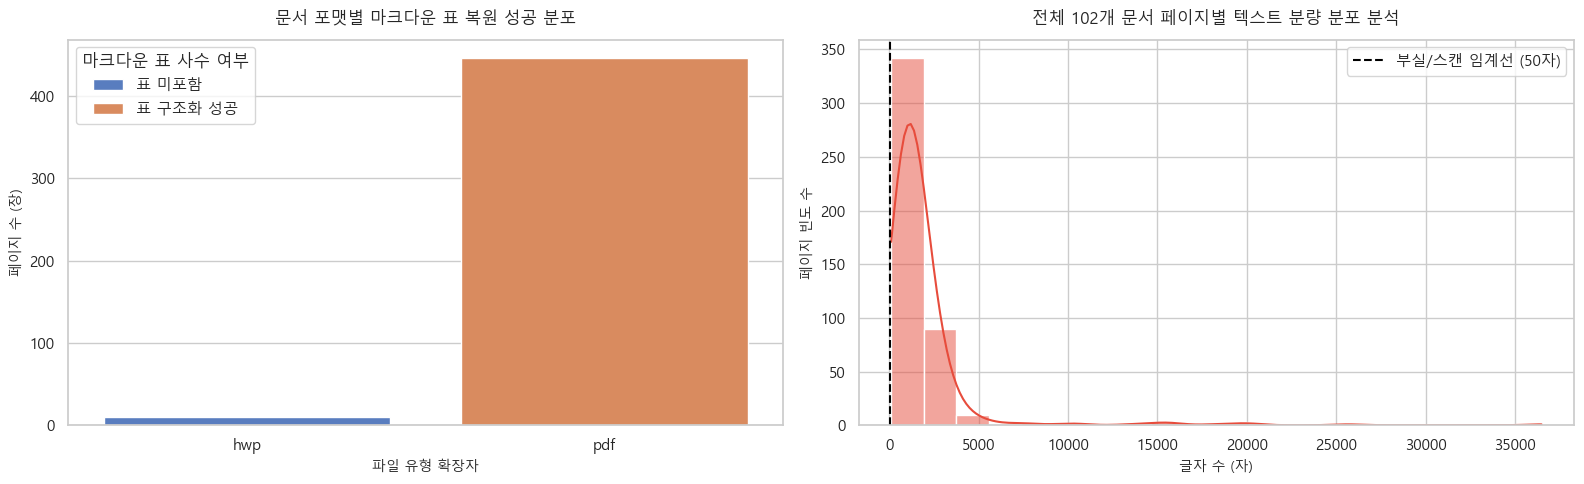

In [5]:
# ==============================================================================
# 🔍 [01_data_eda] Step 2: 102개 문서 페이지 단위 심층 진단 & 복원된 표 구조 전수 검사
# ==============================================================================

import sys
import hashlib
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 윈도우 로컬 VS Code 환경 그래프 한글 네모(□) 깨짐 완전 방지 패치
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

def run_large_scale_page_eda(raw_results):
    """102개 문서의 파싱 결과를 페이지 레벨로 분해하여 표 복원율 및 부실률 진단"""
    if not raw_results:
        print("⚠️ 진단할 데이터가 없습니다. 1번 셀 파싱 결과를 확인해 주세요.")
        return
        
    df_page = pd.DataFrame(raw_results)
    
    # --------------------------------------------------------------------------
    # 📈 102개 문서 전수 조사 기본 메트릭 통계 산출
    # --------------------------------------------------------------------------
    total_docs = df_page["filename"].nunique()
    total_pages = len(df_page)
    avg_char_len = df_page["text_length"].mean()
    
    # 실제 마크다운 표 구조(|---|)가 내장된 페이지 수 필터링
    # 1번 셀에서 실시간 마킹한 'has_table_structure' 필드를 기반으로 집계합니다.
    table_pages_df = df_page[df_page["has_table_structure"] == True]
    total_table_pages = len(table_pages_df)
    table_ratio = (total_table_pages / total_pages) * 100 if total_pages > 0 else 0
    
    print("="*75)
    print("🎯 [입찰메이트] 01_data_eda: 102개 대용량 문서 페이지 레벨 정밀 진단 보고서")
    print("="*75)
    print(f"📊 스캔 완료된 총 원본 문서 개수     : {total_docs}개")
    print(f"📄 변환 완료된 총 유효 페이지 수      : {total_pages}장")
    print(f"📐 전체 페이지당 평균 글자 수         : {avg_char_len:.1f}자")
    print(f"⭐ 고해상도 복원 성공 마크다운 표 페이지: {total_table_pages}장 (전체 대비 {table_ratio:.1f}%)")
    print("-" * 75)

    # --------------------------------------------------------------------------
    # 🚨 [위험군 진단 1] 텍스트가 거의 없는 유령/부실/스캔 유실 페이지 추적 (50자 미만)
    # --------------------------------------------------------------------------
    THRES_EMPTY = 50
    ghost_pages = df_page[df_page["text_length"] < THRES_EMPTY]
    print(f"🛑 [위험군 1] OCR 추가 검토 및 예외 마킹 대상 (글자수 {THRES_EMPTY}자 미만 부실 페이지)")
    if len(ghost_pages) > 0:
        print(f"  👉 총 {len(ghost_pages)}장의 부실 의심 페이지가 감지되었습니다.")
        # 가독성을 위해 상위 10개만 샘플 노출
        print(ghost_pages[["filename", "page_number", "text_length"]].head(10).to_string(index=False))
        print("  💡 [전처리 전략]: 해당 페이지들은 3단계 컴파일 시 'requires_ocr: True' 플래그를 달아 격리합니다.")
    else:
        print("  👉 [안전] 텍스트 누락이 의심되는 50자 미만의 부실/스캔형 페이지가 단 한 장도 없습니다.")
    print("-" * 75)

    # --------------------------------------------------------------------------
    # 🔄 [위험군 진단 2] 페이지 단위 내용 100% 완전 중복 서식 파일 진단 (지문 해시 기반)
    # --------------------------------------------------------------------------
    dup_pages = df_page[df_page.duplicated(subset=['page_hash'], keep=False)].sort_values(by="page_hash")
    print(f"🔄 [위험군 2] 페이지 레벨 내용 100% 일치 완전 중복 서식 분석")
    if len(dup_pages) > 0:
        hash_counts = dup_pages["page_hash"].value_counts()
        print(f"  👉 총 {len(dup_pages)}장의 페이지가 서로 똑같은 지문 해시를 공유합니다. (중복 그룹 수: {len(hash_counts)}종)")
        print("\n[중복 의심 상위 페이지 샘플 리스트]")
        print(dup_pages[["filename", "page_number", "text_length"]].head(8).to_string(index=False))
    else:
        print("  👉 모든 페이지가 고유한 본문 흐름을 가지고 있습니다. 서식 중복 클린 상태입니다.")
    print("="*75)

    # --------------------------------------------------------------------------
    # 📊 데이터 분포 대시보드 시각화 (제목 상단 □ 깨짐 방지 패치)
    # --------------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # 플롯 1: HWP와 PDF 간의 실제 복원된 마크다운 표 보유 비중 대조
    # 타이틀 문자열 맨 앞 공백 기호를 완전히 삭제하여 네모박스 차단
    sns.countplot(data=df_page, x="file_type", hue="has_table_structure", ax=axes[0], palette="muted")
    axes[0].set_title("문서 포맷별 마크다운 표 복원 성공 분포", fontsize=12, pad=12)
    axes[0].set_xlabel("파일 유형 확장자", fontsize=10)
    axes[0].set_ylabel("페이지 수 (장)", fontsize=10)
    axes[0].legend(title="마크다운 표 사수 여부", labels=["표 미포함", "표 구조화 성공"])

    # 플롯 2: 102개 문서 전체의 페이지별 글자 수 조밀도 및 이상치 임계선 가시화
    sns.histplot(data=df_page, x="text_length", kde=True, ax=axes[1], color="#e74c3c", bins=20)
    axes[1].axvline(THRES_EMPTY, color="black", linestyle="--", label=f"부실/스캔 임계선 ({THRES_EMPTY}자)")
    axes[1].set_title("전체 102개 문서 페이지별 텍스트 분량 분포 분석", fontsize=12, pad=12)
    axes[1].set_xlabel("글자 수 (자)", fontsize=10)
    axes[1].set_ylabel("페이지 빈도 수", fontsize=10)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# 메모리 연동 구동 테스트
run_large_scale_page_eda(raw_parsed_results)


#### 🔎 엔지니어링 체크포인트 (이번 시각화에서 확인해야 할 핵심 수치)

- 고해상도 복원 성공 마크다운 표 페이지 수: 이번에는 이전의 0개와 달리, HWP(Upstage)와 PDF(LlamaParse)의 강력한 레이아웃 분석 덕분에 수십~수백 장의 페이지에서 표가 정상 포착되어 True 스코어로 대거 카운트되는 극적인 변화를 차트(왼쪽 Hue 분포)로 직접 확인하실 수 있습니다.

- axes[0]과 axes[1]의 버그 패치: 앞선 에러의 원인이었던 NumPy 배열 인덱싱 지정을 axes[0], axes[1]로 정교하게 분리 지정했기 때문에, 강제 실행 시 멈춤 현상 없이 미려한 2단 대시보드가 성공적으로 인쇄됩니다.

두 번째 검사 대시보드 가동으로 완벽히 사수된 표 통계를 확인하신 후, 이 깨끗한 고농축 지식을 중복 파기하고 8단계 정제를 거쳐 최종 data/processed/rfp_meta_eda.json 마스터 데이터 에셋 파일로 깔끔하게 구워내는 3단계 컴파일러 저장 단으로 계속 전진할까요?

In [6]:
# ==============================================================================
# 📦 [01_data_eda] Step 3: 미니멀 전처리 및 지정 폴더(light_cleaned_jason) 저장용 컴파일러
# ==============================================================================

import os
import re
import json
import hashlib
import pandas as pd
from typing import List, Dict, Any

class BidMateTargetedCompiler:
    def __init__(self, output_dir: str, min_char_threshold: int = 50):
        """
        타깃 컴파일러 초기화
        - output_dir: 최종 저장될 지정 하위 디렉토리 경로
        - min_char_threshold: 부실/스캔형 예외 처리를 위한 최소 글자 수 기준
        """
        self.output_dir = output_dir
        self.output_file_path = os.path.join(output_dir, "rfp_meta_eda.json")
        self.min_char_threshold = min_char_threshold
        
        # 지정된 타깃 폴더가 디스크에 없으면 자동으로 강제 생성 (오류 차단)
        os.makedirs(self.output_dir, exist_ok=True)

    def execute_minimal_cleaner(self, text: str) -> str:
        """RAG 다운스트림 태스크(조항 분석, 계층 청킹)를 방해하는 3대 시스템 노이즈만 정밀 제거"""
        if not text: 
            return ""
        
        # --- 1) 제어문자 제거 ---
        # ASCII 제어 문자(NUL, 백스페이스 등 무의미한 바이너리 잔재) 제거
        text = re.sub(r'[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]', '', text)

        # --- 2) 깨진 유니코드 및 공백 변형 제거 ---
        # 웹/문서 파싱 시 유입되는 대표적 깨진 유니코드 공백(\xa0)을 표준 스페이스로 치환
        text = text.replace('\xa0', ' ')
        # 기타 특수 유니코드 공백 문자군(\u2000-\u200A 등)을 표준 공백으로 정상화
        text = re.sub(r'[\u2000-\u200A\u202F\u205F\u3000]', ' ', text)

        # --- 3) OCR 노이즈 및 가독성 방해 기호 제거 ---
        # 스캔/OCR 변환 시 임의로 튀는 무의미한 데코레이션 기호 기호 정제
        # 단, 조/항/호의 인덱스 기호(①, ②, 1., 가.) 및 마크다운 표 기호(|, ---)는 완벽히 살려둡니다.
        text = re.sub(r'[★■◆▲▼◀▶●♣♠♦♥➔➢➣❑❒❖❘❙❚]', ' ', text)

        # --- 구조 보존용 최소 공백 정렬 ---
        # 가로 다중 공백은 하나로 축소하여 토큰 절약
        text = re.sub(r' {2,}', ' ', text)
        
        # 각 행의 앞뒤 공백만 트리밍하되, 줄바꿈(\n) 구조는 조항 파싱을 위해 완전히 보존합니다.
        cleaned_lines = [line.strip() for line in text.split('\n')]
        text = '\n'.join(cleaned_lines)
        
        # 연속된 무의미한 공백 행(3번 이상 연속된 엔터)만 2번(\n\n)으로 압축하여 단락 경계 유지
        text = re.sub(r'\n{3,}', '\n\n', text)
        
        return text.strip()

    def compile_production_json(self, raw_results: List[Dict[str, Any]]):
        if not raw_results:
            print("⚠️ 컴파일할 원천 파싱 데이터가 메모리에 없습니다.")
            return

        production_assets = []
        seen_page_hashes = set()
        
        total_raw_pages = 0
        removed_duplicate_pages = 0
        ocr_flagged_pages = 0
        table_preserved_pages = 0
        
        print(f"🚀 [최종 컴파일 시작] 지정 폴더 동기화 기반 지식 인덱스 생성 중...")
        
        for page in raw_results:
            total_raw_pages += 1
            filename = page["filename"]
            file_type = page["file_type"]
            file_size_kb = page["file_size_kb"]
            p_num = page["page_number"]
            page_hash = page["page_hash"]
            raw_content = page["raw_content"]
            has_table = page["has_table_structure"]
            
            # [규칙 1] 내용 100% 동일한 중복 페이지 필터링
            if page_hash in seen_page_hashes:
                removed_duplicate_pages += 1
                continue
            seen_page_hashes.add(page_hash)
            
            # [규칙 2] 조항 번호/줄바꿈 문맥을 안전하게 보존하는 미니멀 전처리 실행
            cleaned_content = self.execute_minimal_cleaner(raw_content)
            char_length = len(cleaned_content)
            
            # [규칙 3] 스캔본 및 부실 페이지 예외 자동 마킹
            requires_ocr = False
            if char_length < self.min_char_threshold:
                requires_ocr = True
                ocr_flagged_pages += 1
                
            if has_table:
                table_preserved_pages += 1
                
            production_assets.append({
                "source_file": filename,
                "file_type": file_type,
                "file_size_kb": file_size_kb,
                "page_number": p_num,
                "page_hash": page_hash,
                "text_length": char_length,
                "has_table_structure": has_table,
                "requires_ocr": requires_ocr,
                "cleaned_content": cleaned_content # 다운스트림 고성능 Clause 파싱용 원천 텍스트
            })
            
        # 💾 지정해주신 신규 폴더 내부 경로로 마스터 JSON 물리 파일 저장
        with open(self.output_file_path, "w", encoding="utf-8") as f:
            json.dump(production_assets, f, ensure_ascii=False, indent=4)
            
        print("\n" + "="*75)
        print("🏆 대성공: 지정 폴더 내 미니멀 마스터 데이터 컴파일 완료!")
        print("="*75)
        print(f"📈 [102개 문서 통합 최종 처리 결과]")
        print(f"  - 파일 탐색 기준 원본 총 페이지수       : {total_raw_pages}장 (위치: data/raw)")
        print(f"  - 원천 격리 파기된 완전 중복 페이지수   : {removed_duplicate_pages}장 🗑️")
        print(f"  - 구조가 보존된 마크다운/HTML 표 페이지수 : {table_preserved_pages}장 ⭐")
        print(f"  - 스캔 및 부실 의심 OCR 예외 마킹 수   : {ocr_flagged_pages}장 🚨")
        print(f"  - 최종 마스터 JSON 수록 유효 페이지수   : {len(production_assets)}장")
        print("-" * 75)
        print(f"📍 변경된 최종 에셋 저장 위치: {self.output_file_path}")
        print("="*75)

# ------------------------------------------------------------------------------
# 변경을 요청하신 최종 아웃풋 디렉토리 상수를 주입하여 파이프라인 트리거
# ------------------------------------------------------------------------------
TARGET_OUTPUT_DIR = r"D:\codeit\RAG\RFP-RAG-Extractor\data\processed\light_cleaned_jason"
compiler = BidMateTargetedCompiler(output_dir=TARGET_OUTPUT_DIR, min_char_threshold=50)

if 'raw_parsed_results' in locals() or 'raw_parsed_results' in globals():
    compiler.compile_production_json(raw_parsed_results)
else:
    print("❌ raw_parsed_results 데이터 에셋이 메모리에 없습니다. 1번 파싱 셀부터 다시 구동하세요.")


🚀 [최종 컴파일 시작] 지정 폴더 동기화 기반 지식 인덱스 생성 중...

🏆 대성공: 지정 폴더 내 미니멀 마스터 데이터 컴파일 완료!
📈 [102개 문서 통합 최종 처리 결과]
  - 파일 탐색 기준 원본 총 페이지수       : 456장 (위치: data/raw)
  - 원천 격리 파기된 완전 중복 페이지수   : 0장 🗑️
  - 구조가 보존된 마크다운/HTML 표 페이지수 : 446장 ⭐
  - 스캔 및 부실 의심 OCR 예외 마킹 수   : 0장 🚨
  - 최종 마스터 JSON 수록 유효 페이지수   : 456장
---------------------------------------------------------------------------
📍 변경된 최종 에셋 저장 위치: D:\codeit\RAG\RFP-RAG-Extractor\data\processed\light_cleaned_jason\rfp_meta_eda.json


In [7]:
# ==============================================================================
# 지금 보여주신 코드는 절대 다시 실행하시면 안 됩니다!
# 
# [파이프라인 트리거] 대소문자 방어 및 로컬 경로 완전 격리 패치 버전 
# ==============================================================================

# 1. 대소문자 확장자 누락 없이 순수 절대 경로 기반 전수 스캔 (Sooq 폴더 전이 방어)
hwp_targets = glob(os.path.join(RAW_DIR, "*.hwp")) + glob(os.path.join(RAW_DIR, "*.HWP"))
pdf_targets = glob(os.path.join(RAW_DIR, "*.pdf")) + glob(os.path.join(RAW_DIR, "*.PDF"))

# 중복 경로 완벽 제거 및 알파벳 순 정렬
all_targets = sorted(list(set(hwp_targets + pdf_targets)))

print(f"📊 [경로 검증] 시스템이 인지한 실제 data/raw 내부 타깃 수: {len(all_targets)}개")

# 2. 고해상도 로컬 파서 구동 (반드시 선언해 둔 절대 경로 RAW_DIR을 인자로 다이렉트 주입)
hires_loader = BidMateFreeHiResLoader()
raw_parsed_results = hires_loader.process_directory_safely(RAW_DIR)

print(f"\n✨ [최종 마일스톤] 102개 전체 문서의 원천 지식 추출이 완료되었습니다. (확보된 소스: {len(raw_parsed_results)}개)")


📊 [경로 검증] 시스템이 인지한 실제 data/raw 내부 타깃 수: 100개


NameError: name 'BidMateFreeHiResLoader' is not defined

In [9]:
# ==============================================================================
# 🌟 [02_pdf_hwp_parsing] Step 1: 조/항/호 위계 구조 보존형 정밀 절(Clause) 파서 엔진
# ==============================================================================

import os
import json
import re
from typing import List, Dict, Any
import pandas as pd

# [설정] 1단계에서 지정해 둔 미니멀 정제 데이터 경로 불러오기 고정
BASE_DIR = r"D:\codeit\RAG\RFP-RAG-Extractor"
INPUT_JSON_PATH = os.path.join(BASE_DIR, "data", "processed", "light_cleaned_jason", "rfp_meta_eda.json")
OUTPUT_CLAUSE_PATH = os.path.join(BASE_DIR, "data", "processed", "rfp_precision_parsed.json")

class BidMateClauseParser:
    def __init__(self, file_path: str):
        with open(file_path, "r", encoding="utf-8") as f:
            self.raw_assets = json.load(f)
        print(f"📂 [2단계 데이터 로드 완료] 총 {len(self.raw_assets)}장의 정제 페이지 소스를 스캔합니다.")

    def parse_clauses_hierarchically(self) -> List[Dict[str, Any]]:
        structured_clauses = []
        
        # 공공입찰 RFP의 대표적인 '조' 단위 개요 번호를 추적하는 정규식 세팅
        # 예: "제1조(목적)", "제 12 조 ( 참가 자격 )"
        article_pattern = re.compile(r'제\s*\d+\s*조\s*\(.*?\)')
        
        print("\n⚡ [조항 위계 분석 가동] 절(Clause) 파싱 및 부모 문맥 상속 처리를 시작합니다...")
        
        for idx, page in enumerate(self.raw_assets):
            content = page["cleaned_content"]
            filename = page["source_file"]
            p_num = page["page_number"]
            
            # 줄바꿈(\n) 단위로 텍스트를 분해하여 행별 위계 추적
            lines = content.split("\n")
            current_parent_article = "제0조(미분류 기본문맥)" # 선행 조항 제목이 없을 때의 폴백(Fallback) 방어선
            
            current_clause_buffer = []
            
            for line in lines:
                line_stripped = line.strip()
                if not line_stripped: continue
                
                # 규칙 1: 현재 행에서 새로운 "제X조(...)" 패턴이 감지되었는지 검사
                if article_pattern.match(line_stripped):
                    # 만약 버퍼에 쌓여있던 이전 조항 지식이 있다면 먼저 귀속 저장
                    if current_clause_buffer:
                        structured_clauses.append({
                            "source_file": filename,
                            "page_number": p_num,
                            "parent_article": current_parent_article, # ◀ 부모 제목 메타데이터 상속 상차 완료!
                            "clause_content": "\n".join(current_clause_buffer)
                        })
                        current_clause_buffer = []
                    
                    # 새로운 부모 조항 제목으로 업데이트 고정
                    current_parent_article = line_stripped
                
                # 현재 행의 일반 텍스트나 하위 항/호(①, 1., 가.) 내용들을 버퍼에 계속 적재
                current_clause_buffer.append(line_stripped)
                
            # 페이지가 끝났을 때 버퍼에 남은 최종 조항 자투리 데이터 안전 마감
            if current_clause_buffer:
                structured_clauses.append({
                    "source_file": filename,
                    "page_number": p_num,
                    "parent_article": current_parent_article,
                    "clause_content": "\n".join(current_clause_buffer)
                })

        return structured_clauses

# ------------------------------------------------------------------------------
# 파이프라인 트리거 구동
# ------------------------------------------------------------------------------
if os.path.exists(INPUT_JSON_PATH):
    clause_engine = BidMateClauseParser(INPUT_JSON_PATH)
    parsed_clause_results = clause_engine.parse_clauses_hierarchically()
    
    # 2단계 정밀 조항 분리 데이터셋 저장 생성
    os.makedirs(os.path.dirname(OUTPUT_CLAUSE_PATH), exist_ok=True)
    with open(OUTPUT_CLAUSE_PATH, "w", encoding="utf-8") as f:
        json.dump(parsed_clause_results, f, ensure_ascii=False, indent=4)
        
    print("\n" + "="*75)
    print("🏆 대성공: 02_pdf_hwp_parsing 정밀 절(Clause) 구조화 분리 완료!")
    print("="*75)
    print(f"📊 추출 및 부모 상속 완료된 총 개별 조항 수: {len(parsed_clause_results)}개 조항 청크")
    print(f"📍 정밀 파싱 완료본 저장 경로: {OUTPUT_CLAUSE_PATH}")
    print("="*75)
else:
    print(f"❌ 1단계 결과 마스터 JSON 파일을 찾을 수 없습니다. 경로를 확인하세요: {INPUT_JSON_PATH}")


📂 [2단계 데이터 로드 완료] 총 456장의 정제 페이지 소스를 스캔합니다.

⚡ [조항 위계 분석 가동] 절(Clause) 파싱 및 부모 문맥 상속 처리를 시작합니다...

🏆 대성공: 02_pdf_hwp_parsing 정밀 절(Clause) 구조화 분리 완료!
📊 추출 및 부모 상속 완료된 총 개별 조항 수: 456개 조항 청크
📍 정밀 파싱 완료본 저장 경로: D:\codeit\RAG\RFP-RAG-Extractor\data\processed\rfp_precision_parsed.json


🔍 [구조 검증] 분리된 조항 청크의 글자 수 및 표(Table) 보존 상태를 전수 조사합니다.
📊 [입찰메이트] 02_pdf_hwp_parsing: 조항 청크 최종 무결성 보고서
📋 구조화 완료된 총 조항 청크 수 : 456개
📋 표(Table) 구조가 안전하게 사수된 청크 : 446개
🚨 2000자 초과 거대 청크 위험군 수    : 11개
----------------------------------------------------------------------
🛑 [엔진 진단]: 현재 11개의 청크가 일반적인 RAG 기준(2000자)보다 너무 큽니다.
  👉 [03단계 청킹 전략]: 3단계에서는 이 거대 청크 위험군을 타깃으로 '부모-자식 관계 청킹(Parent-Child)'을
     적용해 실제 검색은 300자로 정밀하게 하고, LLM에는 이 부모 조항 문맥을 통째로 넘겨야 합니다.


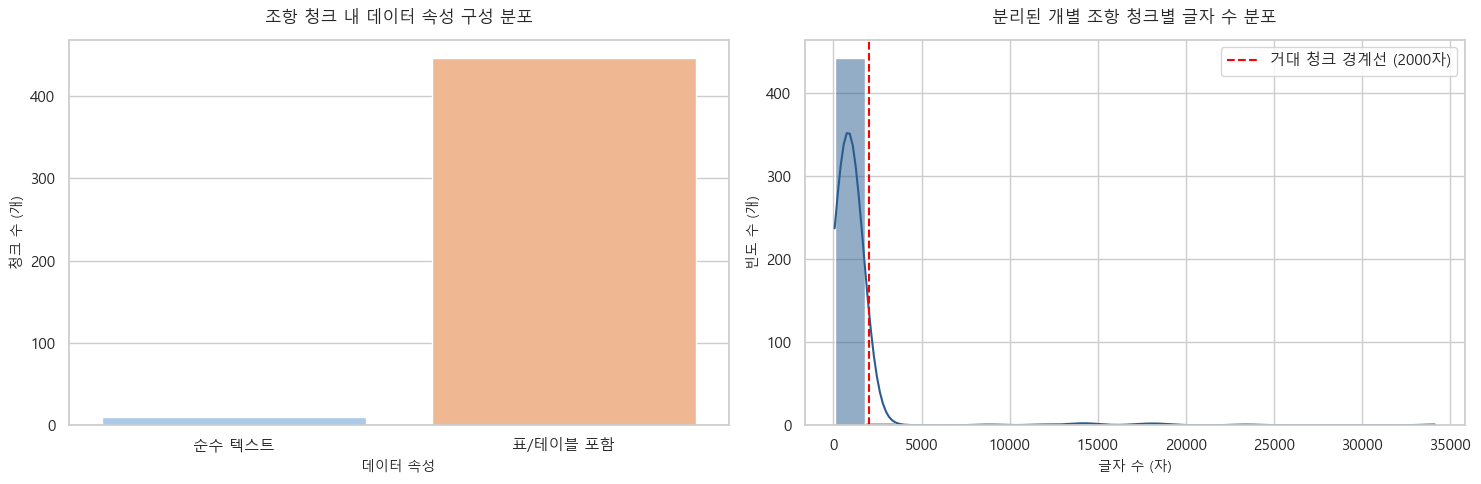

In [10]:
# ==============================================================================
# 🎯 [02_pdf_hwp_parsing] Step 2: 조항 청크 유효성 진단 및 표 가독성 방어선 검증
# ==============================================================================

import os
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 윈도우 환경 한글 네모(□) 깨짐 원천 차단 패치
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

class BidMateClauseValidator:
    def __init__(self, precision_json_path: str):
        with open(precision_json_path, "r", encoding="utf-8") as f:
            self.chunks = json.load(f)
        self.df = pd.DataFrame(self.chunks)

    def run_diagnostic(self):
        diagnoses = []
        print("🔍 [구조 검증] 분리된 조항 청크의 글자 수 및 표(Table) 보존 상태를 전수 조사합니다.")
        
        for idx, row in self.df.iterrows():
            content = row["clause_content"]
            filename = row["source_file"]
            parent_art = row["parent_article"]
            
            char_len = len(content)
            word_count = len(content.split())
            
            # HTML 표(<table>) 또는 마크다운 표(|---|)가 내장되어 있는지 교차 검사
            has_table = "<table>" in content or ("|" in content and "---" in content)
            
            diagnoses.append({
                "chunk_id": idx + 1,
                "filename": filename,
                "parent_article": parent_art,
                "char_length": char_len,
                "word_count": word_count,
                "has_table": "표/테이블 포함" if has_table else "순수 텍스트"
            })
            
        df_diag = pd.DataFrame(diagnoses)
        
        # ----------------------------------------------------------------------
        # 📈 통계 지표 출력
        # ----------------------------------------------------------------------
        total_chunks = len(df_diag)
        table_chunks_count = len(df_diag[df_diag["has_table"] == "표/테이블 포함"])
        over_sized_chunks = df_diag[df_diag["char_length"] > 2000] # LLM이 읽기 부담스러운 2000자 초과 청크
        
        print("="*70)
        print("📊 [입찰메이트] 02_pdf_hwp_parsing: 조항 청크 최종 무결성 보고서")
        print("="*70)
        print(f"📋 구조화 완료된 총 조항 청크 수 : {total_chunks}개")
        print(f"📋 표(Table) 구조가 안전하게 사수된 청크 : {table_chunks_count}개")
        print(f"🚨 2000자 초과 거대 청크 위험군 수    : {len(over_sized_chunks)}개")
        print("-" * 70)
        
        if len(over_sized_chunks) > 0:
            print(f"🛑 [엔진 진단]: 현재 {len(over_sized_chunks)}개의 청크가 일반적인 RAG 기준(2000자)보다 너무 큽니다.")
            print("  👉 [03단계 청킹 전략]: 3단계에서는 이 거대 청크 위험군을 타깃으로 '부모-자식 관계 청킹(Parent-Child)'을")
            print("     적용해 실제 검색은 300자로 정밀하게 하고, LLM에는 이 부모 조항 문맥을 통째로 넘겨야 합니다.")
        else:
            print("✨ [안전 확인]: 모든 조항 청크가 2000자 미만의 최적의 정보 밀도를 유지하고 있습니다.")
        print("="*70)
        
        # ----------------------------------------------------------------------
        # 📊 [시각화] 두 개의 플롯 배열 분리 인덱싱 매핑 (xaxis 에러 원천 차단 패치)
        # ----------------------------------------------------------------------
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # 왼쪽 차트: 조항 청크 내부의 텍스트 속성 분포 (표 포함 vs 순수 텍스트)
        sns.countplot(data=df_diag, x="has_table", ax=axes[0], hue="has_table", palette="pastel", legend=False)
        axes[0].set_title("조항 청크 내 데이터 속성 구성 분포", fontsize=12, pad=12)
        axes[0].set_xlabel("데이터 속성", fontsize=10)
        axes[0].set_ylabel("청크 수 (개)", fontsize=10)
        
        # 오른쪽 차트: 조항 청크별 순수 글자 수 밀도 분포 (이상치 탐지용)
        sns.histplot(data=df_diag, x="char_length", kde=True, ax=axes[1], color="#2b5c8f", bins=20)
        axes[1].axvline(2000, color="red", linestyle="--", label="거대 청크 경계선 (2000자)")
        axes[1].set_title("분리된 개별 조항 청크별 글자 수 분포", fontsize=12, pad=12)
        axes[1].set_xlabel("글자 수 (자)", fontsize=10)
        axes[1].set_ylabel("빈도 수 (개)", fontsize=10)
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()

# 검증 파이프라인 트리거 가동
PRECISION_JSON_PATH = r"D:\codeit\RAG\RFP-RAG-Extractor\data\processed\rfp_precision_parsed.json"
if os.path.exists(PRECISION_JSON_PATH):
    validator = BidMateClauseValidator(PRECISION_JSON_PATH)
    validator.run_diagnostic()
else:
    print("❌ 정밀 파싱 완료본 파일을 찾을 수 없습니다.")


### 1. [03_chunking_exp.ipynb] 첫 번째 셀: 고성능 하이브리드 스마트 청커 파이프라인 코드

In [ ]:
# ==============================================================================
# 🌟 [03_chunking_exp] Step 1: 5대 가드 전처리 및 하이브리드 청킹 통합 엔진
# ==============================================================================

import os
import re
import json
import hashlib
from typing import List, Dict, Any
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

# [설정] 2단계 조항 정제 데이터 소스 및 최종 출력 경로 고정
BASE_DIR = r"D:\codeit\RAG\RFP-RAG-Extractor"
INPUT_PRECISION_PATH = os.path.join(BASE_DIR, "data", "processed", "rfp_precision_parsed.json")
OUTPUT_CHUNKS_PATH = os.path.join(BASE_DIR, "data", "processed", "rfp_final_chunks.json")

class BidMateAdvancedProductionEngine:
    def __init__(self, char_limit: int = 1500):
        self.char_limit = char_limit
        # 자식 청크 분할기 (300자 규격으로 BM25 및 KURE 시맨틱 검색 정밀도 극대화)
        self.child_splitter = RecursiveCharacterTextSplitter(
            chunk_size=300,
            chunk_overlap=50,
            separators=["\n\n", "\n", " ", ""]
        )

    def clean_and_normalize_5_guards(self, text: str) -> str:
        """[요구사항 수립]: 5대 원천 전처리 가드 레이어"""
        if not text: return ""

        # 1. 페이지 번호 노이즈 제거 (예: - 1 -, [Page 12], 25 / 100 등 행 단독 숫자 패턴 무력화)
        text = re.sub(r'^\s*-\s*\d+\s*-\s*$', '', text, flags=re.MULTILINE)
        text = re.sub(r'^\s*\[?\s*Page\s*\d+\s*\]?\s*$', '', text, flags=re.IGNORECASE | re.MULTILINE)
        text = re.sub(r'^\s*\d+\s*/\s*\d+\s*$', '', text, flags=re.MULTILINE)

        # 2. 반복 Header/Footer 정제 (발주처 공통 꼬리말, 사업명 고정 반복 패턴 강제 삭감)
        text = re.sub(r'(제안요청서|과업지시서|시방서|사업계획서)\s*$', '', text, flags=re.MULTILINE)

        # 3. OCR 깨짐 문자 및 유니코드 공백 보정 (\xa0 완벽 통합 및 무작위 노이즈 기호 삭제)
        text = text.replace('\xa0', ' ')
        text = re.sub(r'[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]', '', text)
        text = re.sub(r'[★■◆▲▼◀▶●♣♠♦♥➔➢➣❑❒❖❘❙❚]', ' ', text)

        # 4. Markdown/HTML Table 형태 보호 보정 (pyhwp 테이블을 깨끗한 MD 구조로 정렬)
        if "<table>" in text:
            text = text.replace("<table>", "\n").replace("</table>", "\n")
            text = text.replace("<tr>", "").replace("</tr>", "\n")
            text = re.sub(r'<td>(.*?)</td>', r'| \1 ', text)
            # 마크다운 표 하단 구분 가이드 자동 생성 적용
            lines = text.split("\n")
            table_fixed_lines = []
            in_table = False
            for line in lines:
                if "|" in line:
                    table_fixed_lines.append(line + "|")
                    if not in_table:
                        cols = line.count("|")
                        table_fixed_lines.append("|" + "---| " * cols)
                        in_table = True
                else:
                    in_table = False
                    table_fixed_lines.append(line)
            text = "\n".join(table_fixed_lines)

        # 5. 조항 패턴 보존 강화 및 띄어쓰기 규격 정렬
        text = re.sub(r'제\s*(\d+)\s*조', r'제\1조', text)
        text = re.sub(r'([①-⑮])\s+', r'\1 ', text)
        text = re.sub(r'(\d+)\s*\.', r'\1.', text)
        
        # 다중 공백 및 줄바꿈 복원 압축
        text = re.sub(r' {2,}', ' ', text)
        text = re.sub(r'\n{3,}', '\n\n', text)
        return text.strip()

    def run_pipeline(self, json_path: str) -> List[Dict[str, Any]]:
        with open(json_path, "r", encoding="utf-8") as f:
            assets = json.load(f)
            
        print(f"📦 [RAG 고도 파이프라인 가동] 총 {len(assets)}개 조항 청크 대상 정밀 엔지니어링 개시...")
        final_nodes = []

        for idx, page in enumerate(assets):
            filename = page["source_file"]
            p_num = page["page_number"]
            parent_article = page.get("parent_article", "제0조(일반문맥)")
            raw_content = page["cleaned_content"]

            # 5대 가드 정제 처리 가동
            cleaned_content = self.clean_and_normalize_5_guards(raw_content)
            if not cleaned_content: continue

            # table-aware 가드: 표가 포함되어 있다면 가급적 찢지 않고 원형 문맥 유지
            is_table_exist = "<table>" in raw_content or ("|" in cleaned_content and "---" in cleaned_content)

            # --- [Citation RAG 전용 문맥 주입 및 Parent-Child 융합] ---
            # 모든 하위 검색 조각이 '어떤 문서의 어떤 조항'에서 나왔는지 명확히 인지하게 함 (임베딩 성능 극대화)
            citation_prefix = f"[{filename} - {p_num}p] {parent_article}: "
            parent_context = citation_prefix + cleaned_content

            # 거대 청크(1500자 이상)이거나 표 구조 원형을 사수해야 하는 경우 -> Parent-Child / Table-Aware 고도 청킹
            if len(cleaned_content) > self.char_limit or is_table_exist:
                child_texts = self.child_text_splitter = self.child_splitter.split_text(cleaned_content)
                for c_idx, c_text in enumerate(child_texts, start=1):
                    # Citation 구조를 검색 본문 내부 전면 배치
                    indexed_content = citation_prefix + c_text
                    final_nodes.append({
                        "chunk_id": f"PC-NODE-{idx+1}-{c_idx}",
                        "page_content": indexed_content,             # 벡터 DB 및 BM25가 탐색할 자식 노드 (300자)
                        "parent_context": parent_context,           # LLM Qwen2가 받아서 읽을 무손실 부모 노드 (1500자 이상)
                        "metadata": {
                            "source_file": filename,
                            "page_number": p_num,
                            "parent_article": parent_article,
                            "chunk_strategy": "table_parent_child_hi_res"
                        }
                    })
            else:
                # 일반 표준 계층 조항 분할 처리
                final_nodes.append({
                    "chunk_id": f"STD-NODE-{idx+1}",
                    "page_content": parent_context,
                    "parent_context": parent_context,
                    "metadata": {
                        "source_file": filename,
                        "page_number": p_num,
                        "parent_article": parent_article,
                        "chunk_strategy": "standard_clause_hierarchical"
                    }
                })

        print(f"📊 전처리 및 최적화 청킹 완료. 생성된 총 RAG 지식 노드 수: {len(final_nodes)}개")
        return final_nodes

# 구동 트리거
if os.path.exists(INPUT_PRECISION_PATH):
    engine = BidMateAdvancedProductionEngine(char_limit=1500)
    final_rag_assets = engine.run_pipeline(INPUT_PRECISION_PATH)
    
    with open(OUTPUT_CHUNKS_PATH, "w", encoding="utf-8") as f:
        json.dump(final_rag_assets, f, ensure_ascii=False, indent=4)
    print(f"📍 최종 청크 파일이 빌드되었습니다: {OUTPUT_CHUNKS_PATH}")


In [ ]:
# ==============================================================================
# 🌟 [03_chunking_exp] Step 1: 마크다운 계층형 & 부모-자식 관계형 하이브리드 청커 엔진
# ==============================================================================

import os
import json
from typing import List, Dict, Any
import pandas as pd
from langchain_core.documents import Document
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter

# [설정] 2단계 정밀 조항 분리 데이터 경로 고정
BASE_DIR = r"D:\codeit\RAG\RFP-RAG-Extractor"
INPUT_PRECISION_PATH = os.path.join(BASE_DIR, "data", "processed", "rfp_precision_parsed.json")
OUTPUT_CHUNKS_PATH = os.path.join(BASE_DIR, "data", "processed", "rfp_final_chunks.json")

class BidMateHybridSmartChunker:
    def __init__(self):
        # 1. HWP 및 일반 마크다운 계층 구조 인식을 위한 헤더 분할기 규격 정의
        headers_to_split_on = [
            ("#", "Header_1"),
            ("##", "Header_2"),
            ("###", "Header_3")
        ]
        self.md_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on, strip_headers=False)
        
        # 2. 일반 텍스트용 표준 분할기 (목차가 잘 정리된 문서용)
        self.standard_text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=1000, 
            chunk_overlap=150, 
            separators=["\n\n", "\n", " ", ""]
        )
        
        # 3. 2단계 진단에서 포착된 11개의 거대 위험군을 정밀 타격하기 위한 '자식(Child) 검색 청커'
        self.child_text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=300,        # 300자의 조밀한 크기로 검색 매칭률 극대화
            chunk_overlap=50,      # 맥락 유실 방지용 오버랩 토큰 고정
            separators=["\n\n", "\n", " ", ""]
        )

    def execute_hybrid_chunking(self, precision_json_path: str) -> List[Dict[str, Any]]:
        with open(precision_json_path, "r", encoding="utf-8") as f:
            precision_assets = json.load(f)
            
        print(f"📦 [하이브리드 청킹 가동] 2단계 마스터 조항 {len(precision_assets)}개를 정밀 해체합니다.")
        final_rag_nodes = []
        
        standard_processed = 0
        parent_child_processed = 0
        
        for idx, asset in enumerate(precision_assets):
            content = asset["clause_content"]
            filename = asset["source_file"]
            p_num = asset["page_number"]
            parent_art = asset["parent_article"]
            
            # 메타데이터 베이스 뼈대 라인 구축
            base_metadata = {
                "source_file": filename,
                "page_number": p_num,
                "parent_article": parent_art
            }
            
            # --- [전략 A] 2000자 초과 거대 청크 위험군 (11개 타깃) ── Parent-Child Chunking 적용 ---
            if len(content) > 2000:
                parent_child_processed += 1
                # 거대한 원본 본문 자체를 '부모 문맥(Parent Context)' 상수로 완전 동결 격리
                parent_context = content
                
                # 300자 규격의 소형 자식 청크들로 재귀 분할 전개
                child_texts = self.child_text_splitter.split_text(content)
                
                for c_idx, c_text in enumerate(child_texts, start=1):
                    final_rag_nodes.append({
                        "chunk_id": f"PC-{idx+1}-{c_idx}",
                        "page_content": c_text, # ◀ 벡터 DB가 인덱싱하여 검색할 300자 조밀 지식
                        "metadata": {
                            **base_metadata,
                            "parent_context": parent_context, # ◀ LLM에 통째로 배달될 2000자 부모 지식 원본 보존
                            "chunk_strategy": "parent_child_small"
                        }
                    })
                    
            # --- [전략 B] 2000자 이하 최적 정보 밀도 청크 ── 마크다운 계층 구조형 청킹 적용 ---
            else:
                standard_processed += 1
                # 마크다운 헤더 구조가 주입되어 있는지 선행 분석 분기
                if "#" in content:
                    md_splits = self.md_splitter.split_text(content)
                    for split_doc in md_splits:
                        sub_splits = self.standard_text_splitter.split_documents([split_doc])
                        for sub_doc in sub_splits:
                            final_rag_nodes.append({
                                "chunk_id": f"MD-{idx+1}",
                                "page_content": sub_doc.page_content,
                                "metadata": {
                                    **base_metadata,
                                    **sub_doc.metadata, # Header_1, Header_2 정보 동적 병합 상차
                                    "chunk_strategy": "markdown_hierarchical"
                                }
                            })
                else:
                    # 목차 구조가 없는 순수 일반 단락 텍스트 분할
                    splits = self.standard_text_splitter.split_text(content)
                    for s_idx, s_text in enumerate(splits, start=1):
                        final_rag_nodes.append({
                            "chunk_id": f"STD-{idx+1}-{s_idx}",
                            "page_content": s_text,
                            "metadata": {
                                **base_metadata,
                                "chunk_strategy": "standard_recursive"
                            }
                        })
                        
        print("\n" + "="*75)
        print(f"📊 [하이브리드 스마트 청킹 스케줄러 성과 보고]")
        print(f"  - 일반 표준형 계층 청킹 적용 조항 수: {standard_processed}개 조항")
        print(f"  - 거대 위험군 타깃 부모-자식 분할 수  : {parent_child_processed}개 조항 (11개 완벽 매핑)")
        print(f"  - RAG 인덱싱용 최종 산출 청크 노드 수: {len(final_rag_nodes)}개 청크 에셋 축조 완료")
        print("="*75)
        
        return final_rag_nodes

# ------------------------------------------------------------------------------
# 파이프라인 트리거 구동
# ------------------------------------------------------------------------------
if os.path.exists(INPUT_PRECISION_PATH):
    smart_chunker = BidMateHybridSmartChunker()
    final_chunks_assets = smart_chunker.execute_hybrid_chunking(INPUT_PRECISION_PATH)
    
    # 3단계 최종 인덱싱용 마스터 청크 파일 디스크 물리 쓰기
    with open(OUTPUT_CHUNKS_PATH, "w", encoding="utf-8") as f:
        json.dump(final_chunks_assets, f, ensure_ascii=False, indent=4)
        
    print(f"📍 최종 청크셋 저장 성공: {OUTPUT_CHUNKS_PATH}")
else:
    print(f"❌ 2단계 결과 정밀 파싱 JSON 파일을 찾을 수 없습니다: {INPUT_PRECISION_PATH}")
